# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 : Fabrizio Tapia
- Alumno 2 : Caterina Martinez Dufour

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [1]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/FabrizioTapia/tuia-dog-recognition-app.git"

!git clone $REPO_URL proyecto
%cd proyecto

Cloning into 'proyecto'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 133 (delta 21), reused 13 (delta 10), pack-reused 97 (from 2)
Receiving objects: 100% (133/133), 2.75 MiB | 6.89 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/proyecto


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations

## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [3]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data/dataset
GPU disponible: True


## 4. Descargar el dataset

In [4]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/data/dataset
dogs.csv  test	train  valid


## 5. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

#### Visualizacion de la distribucion del dataset

In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd


base_path = "data/dataset"
def analizar_carpetas(split):
    split_path = os.path.join(base_path, split)
    if not os.path.exists(split_path):
        print(f"La carpeta {split} no existe.")
        return {}

    # Cuenta cuántos archivos hay dentro de cada subcarpeta de raza
    datos = {}
    for raza in sorted(os.listdir(split_path)):
        raza_path = os.path.join(split_path, raza)
        if os.path.isdir(raza_path):
            num_imagenes = len([f for f in os.listdir(raza_path) if os.path.isfile(os.path.join(raza_path, f))])
            datos[raza] = num_imagenes
    return datos




In [6]:
train_counts = analizar_carpetas("train")
valid_counts = analizar_carpetas("valid")
test_counts = analizar_carpetas("test")

# Armamos un DataFrame para visualizarlo como tabla
df = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Valid": pd.Series(valid_counts),
    "Test": pd.Series(test_counts)
}).fillna(0).astype(int)

# Imprimimos estadísticas generales del dataset
print(f"Número total de razas (clases): {len(df)}")
print(f"Total de imágenes en Train: {df['Train'].sum()}")
print(f"Total de imágenes en Valid: {df['Valid'].sum()}")
print(f"Total de imágenes en Test: {df['Test'].sum()}")
print("\n--- Primeras 10 razas y su distribución de imágenes ---")
print(df.head(10))

Número total de razas (clases): 71
Total de imágenes en Train: 7946
Total de imágenes en Valid: 700
Total de imágenes en Test: 700

--- Primeras 10 razas y su distribución de imágenes ---
                   Train  Valid  Test
Afghan               105     10    10
African Wild Dog     109     10    10
Airedale             117     10    10
American  Spaniel      0     10     0
American Hairless     65     10    10
American Spaniel      89      0    10
Basenji               99     10    10
Basset               159     10    10
Beagle               123     10    10
Bearded Collie        79     10    10


#### Graficamos la distribución del set de entrenamiento para visualizar el balanceo

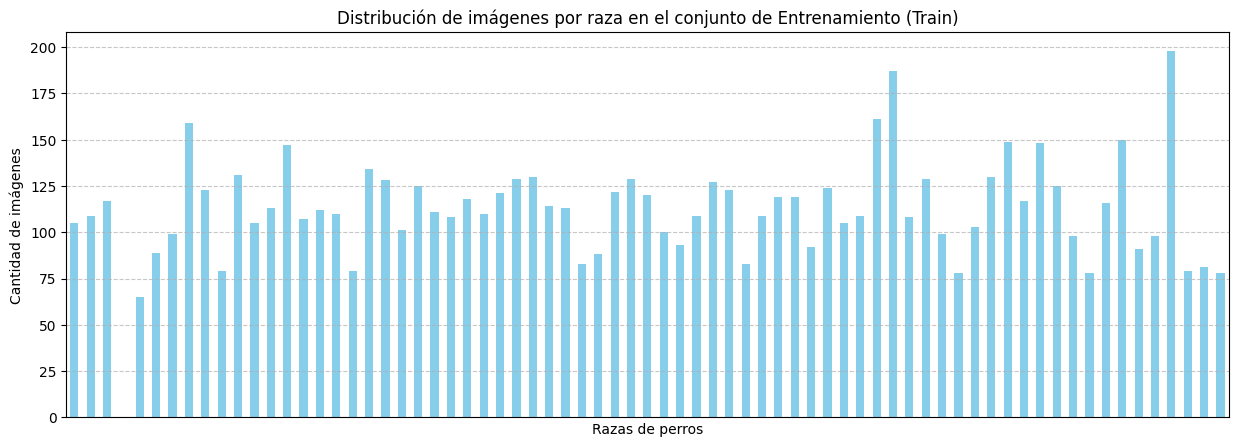

In [7]:
plt.figure(figsize=(15, 5))
df["Train"].plot(kind="bar", color="skyblue")
plt.title("Distribución de imágenes por raza en el conjunto de Entrenamiento (Train)")
plt.xlabel("Razas de perros")
plt.ylabel("Cantidad de imágenes")
plt.xticks([]) # Ocultamos los nombres en el eje X si son muchas para que no se superpongan
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

#### Creamos la carpeta para el dataset independiente

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


!mkdir -p data/dataset_independiente
!gdown "1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h" -O data/dataset_independiente.zip
!unzip -q data/dataset_independiente.zip -d data/dataset_independiente/
!ls data/dataset_independiente

Downloading...
From (original): https://drive.google.com/uc?id=1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h
From (redirected): https://drive.google.com/uc?id=1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h&confirm=t&uuid=aed3279b-1836-4807-8304-c48767407e55
To: /content/proyecto/data/dataset_independiente.zip
100% 67.2M/67.2M [00:00<00:00, 96.2MB/s]
conjunto_independiente_val


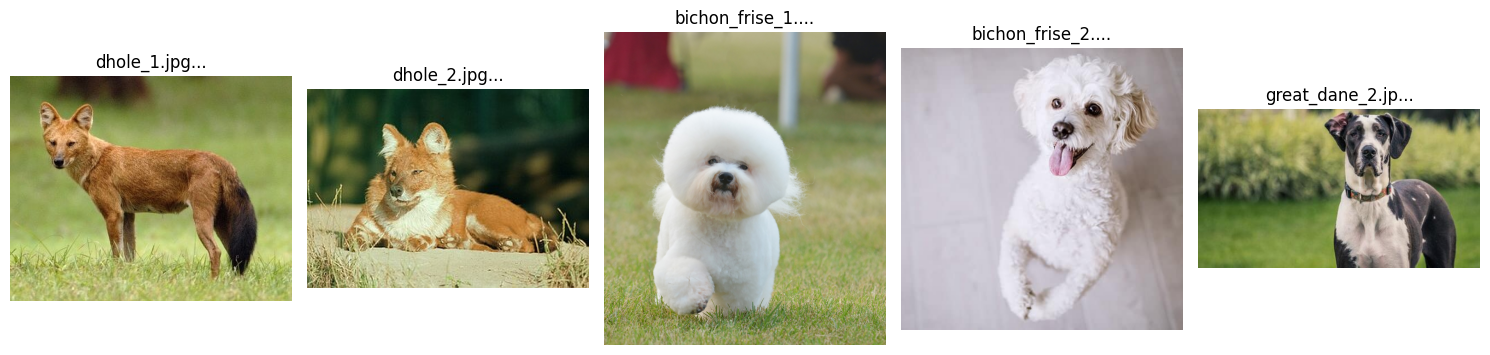

In [9]:
# Buscamos de forma recursiva archivos con extensiones de imagen comunes
ruta_independiente = Path("data/dataset_independiente")
extensiones = ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp"]
archivos_imagen = []

for ext in extensiones:
    archivos_imagen.extend(list(ruta_independiente.rglob(ext)))

#  Tomamos las primeras 5 imágenes encontradas
imagenes_a_mostrar = archivos_imagen[:5]

if not imagenes_a_mostrar:
    print("No se encontraron imágenes en la carpeta. Verificá la extracción del zip.")
else:
    # Armamos la grilla para mostrarlas en una sola fila
    fig, axes = plt.subplots(1, len(imagenes_a_mostrar), figsize=(15, 5))

    # Manejo por si encuentra menos de 5 imágenes y 'axes' no es una lista
    if len(imagenes_a_mostrar) == 1:
        axes = [axes]

    for i, img_path in enumerate(imagenes_a_mostrar):
        img = Image.open(img_path)
        axes[i].imshow(img)
        # Mostramos el nombre del archivo recortado para que no tape el gráfico
        axes[i].set_title(img_path.name[:15] + "...")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

#### Revision de la carpeta intrusa

In [10]:
import os
from pathlib import Path

base_path = Path("data/dataset")
splits = ["train", "valid", "test"]


for split in splits:
    split_path = base_path / split
    if not split_path.exists():
        continue

    print(f"\n[Split: {split}]")
    for folder_path in sorted(split_path.iterdir()):
        if folder_path.is_dir():
            original_name = folder_path.name

            cleaned_name = original_name.strip()

            if original_name != cleaned_name:
                target_path = split_path / cleaned_name
                print(f"Detectada carpeta malformada: '{original_name}'")

                if target_path.exists():
                    print(f" Fusionando archivos dentro de la carpeta correcta: '{cleaned_name}'...")
                    for file in folder_path.iterdir():
                        if file.is_file():
                            os.rename(file, target_path / file.name)
                    os.rmdir(folder_path)

                else:
                    print(f"    -Renombrando directamente a: '{cleaned_name}'")
                    os.rename(folder_path, target_path)

            elif "american" in original_name.lower() or "spaniel" in original_name.lower():
                print(f" Carpeta verificada y limpia: '{original_name}'")

print("\nCONTEO FINAL DE RAZAS POR SPLIT")

for split in splits:
    split_path = base_path / split
    if split_path.exists():
        # Filtramos y contamos solo los directorios reales
        num_carpetas = len([p for p in split_path.iterdir() if p.is_dir()])

        if num_carpetas == 70:
            print(f"{split.capitalize()}: {num_carpetas} carpetas .")
        else:
            print(f"{split.capitalize()}: {num_carpetas} carpetas. (Revisar si quedó algún duplicado).")
    else:
        print(f" La carpeta '{split}' no fue encontrada.")


[Split: train]
 Carpeta verificada y limpia: 'American Hairless'
 Carpeta verificada y limpia: 'American Spaniel'
 Carpeta verificada y limpia: 'Irish Spaniel'
 Carpeta verificada y limpia: 'Japanese Spaniel'

[Split: valid]
 Carpeta verificada y limpia: 'American  Spaniel'
 Carpeta verificada y limpia: 'American Hairless'
 Carpeta verificada y limpia: 'Irish Spaniel'
 Carpeta verificada y limpia: 'Japanese Spaniel'

[Split: test]
 Carpeta verificada y limpia: 'American Hairless'
 Carpeta verificada y limpia: 'American Spaniel'
 Carpeta verificada y limpia: 'Irish Spaniel'
 Carpeta verificada y limpia: 'Japanese Spaniel'

CONTEO FINAL DE RAZAS POR SPLIT
Train: 70 carpetas .
Valid: 70 carpetas .
Test: 70 carpetas .


'American  Spaniel' tiene doble espacio, lo cual altera el orden alfabetico del sistema de carpetas y genera un error que podemos visualizar en la matriz de confusion. Deberemos corregir para el correcto entrenamiento.
Decidimos modificar el nombre de las carpetas y usar una estandarización'snake_case'. Posteriormente se podria aplicar un espejado de carpetas para mayor seguridad

In [11]:
import os

def to_snake_case(name):
    # .lower() pasa todo a minúsculas
    # .split() corta las palabras eliminando CUALQUIER cantidad de espacios extra
    # "_".join() las vuelve a unir usando un solo guión bajo
    return "_".join(name.lower().split())

# Rutas de tus carpetas principales
dataset_paths = [
    "data/dataset/train",
    "data/dataset/valid",
    "data/dataset/test"
]

print("=== Iniciando limpieza de carpetas a snake_case ===")

for base_dir in dataset_paths:
    if not os.path.exists(base_dir):
        print(f"La ruta {base_dir} no existe. Revisá si está bien escrita.")
        continue

    print(f"\nProcesando directorio: {base_dir}")
    carpetas_modificadas = 0

    # Listar todo lo que hay dentro de train o valid
    for folder_name in os.listdir(base_dir):
        old_path = os.path.join(base_dir, folder_name)

        # Nos aseguramos de que sea una carpeta y no un archivo suelto
        if os.path.isdir(old_path):
            new_name = to_snake_case(folder_name)
            new_path = os.path.join(base_dir, new_name)

            # Solo renombra si el nombre viejo es distinto al nuevo
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f"Renombrado: '{folder_name}'  ->  '{new_name}'")
                carpetas_modificadas += 1

    if carpetas_modificadas == 0:
        print("  Todas las carpetas ya estaban limpias.")
    else:
        print(f"  Total de carpetas corregidas en {base_dir}: {carpetas_modificadas}")

print("\n=== Limpieza finalizada con éxito ===")

=== Iniciando limpieza de carpetas a snake_case ===

Procesando directorio: data/dataset/train
Renombrado: 'Clumber'  ->  'clumber'
Renombrado: 'Great Perenees'  ->  'great_perenees'
Renombrado: 'American Spaniel'  ->  'american_spaniel'
Renombrado: 'Airedale'  ->  'airedale'
Renombrado: 'Greyhound'  ->  'greyhound'
Renombrado: 'Irish Wolfhound'  ->  'irish_wolfhound'
Renombrado: 'Dalmation'  ->  'dalmation'
Renombrado: 'Shih-Tzu'  ->  'shih-tzu'
Renombrado: 'Labradoodle'  ->  'labradoodle'
Renombrado: 'Beagle'  ->  'beagle'
Renombrado: 'Borzoi'  ->  'borzoi'
Renombrado: 'Rottweiler'  ->  'rottweiler'
Renombrado: 'Golden Retriever'  ->  'golden_retriever'
Renombrado: 'Labrador'  ->  'labrador'
Renombrado: 'Rhodesian'  ->  'rhodesian'
Renombrado: 'Lhasa'  ->  'lhasa'
Renombrado: 'Bearded Collie'  ->  'bearded_collie'
Renombrado: 'Poodle'  ->  'poodle'
Renombrado: 'Border Collie'  ->  'border_collie'
Renombrado: 'Chinese Crested'  ->  'chinese_crested'
Renombrado: 'Bull Terrier'  ->  'bu

#### Criterios de filtrado de imagenes de baja calidad

A pesar de que las especificaciones del dataset original indican que las imágenes ya se encuentran normalizadas a una resolución de 224x224 píxeles, se implementó una verificación para asegurar la integridad de los datos antes de iniciar el entrenamiento. Los criterios seleccionados y sus justificaciones son los siguientes:



*   **Dimensión Mínima (224 píxeles):** Se incluyó para validar que ninguna imagen hubiera sufrido corrupción o pérdida de datos durante la descarga o descompresión.
*   **Varianza del Laplaciano (Umbral 20.0):** Este método calcula la cantidad de bordes definidos para medir la nitidez de forma matemática. Su revisión es necesaria porque una imagen puede cumplir formalmente con el tamaño de 224x224 píxeles pero ser el resultado de estirar un archivo miniatura pixelado o presentar un desenfoque severo de origen. El umbral de 20.0 se configuró de manera amplia y no restrictiva para detectar únicamente casos extremos de oclusión o fallas graves de enfoque, sin descartar fotos válidas que posean variaciones normales de iluminación o profundidad de campo.





In [12]:
import os
import cv2
from pathlib import Path

base_path = Path("data/dataset")
splits = ["train", "valid", "test"]

laplacian_threshold = 20.0
min_size = 224

for split in splits:
    split_path = base_path / split
    if not split_path.exists():
        continue

    fail_size_count = 0
    fail_blur_count = 0
    total_images = 0

    for root, _, files in os.walk(split_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                total_images += 1
                img_path = os.path.join(root, file)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                h, w = img.shape
                if h < min_size or w < min_size:
                    fail_size_count += 1
                    continue

                variance = cv2.Laplacian(img, cv2.CV_64F).var()
                if variance < laplacian_threshold:
                    fail_blur_count += 1

    print(f"Split: {split}")
    print(f"  Total imagenes: {total_images}")
    print(f"  Total error Resolucion: {fail_size_count}")
    print(f"  Alto desenfoque: {fail_blur_count}")

Split: train
  Total imagenes: 7946
  Total error Resolucion: 0
  Alto desenfoque: 0
Split: valid
  Total imagenes: 700
  Total error Resolucion: 0
  Alto desenfoque: 0
Split: test
  Total imagenes: 700
  Total error Resolucion: 0
  Alto desenfoque: 0


## 6. Preprocesamiento

TO-DO: definir y justificar resize, normalizacion y data augmentation (horizontal flip,
rotacion, blur, variaciones de brillo y contraste, ruido).

resize y normalizacion

In [13]:
import glob
from PIL import Image
import torchvision.transforms as transforms

transform_etapa2 = transforms.Compose([
    transforms.Resize((224, 224)),
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

ruta_imagen = glob.glob("data/dataset/train/*/*.jpg")[0]
imagen = Image.open(ruta_imagen)
tensor_normalizado = transform_etapa2(imagen)
print("Dimensiones originales:", imagen.size)
print("Forma del tensor resultante:", tensor_normalizado.shape)



Dimensiones originales: (224, 224)
Forma del tensor resultante: torch.Size([3, 224, 224])


Horizontal flip: Simula que el perro mire en la dirección opuesta, enseñando al modelo que la orientación no cambia la raza.

Rotación: Hace al modelo robusto frente a fotos tomadas con la cámara inclinada o en ángulos no perfectamente rectos.

Blur (Desenfoque): Obliga a la red neuronal a depender de formas generales en lugar de memorizar texturas o bordes perfectos.

Brillo y contraste: Simula variaciones de iluminación del mundo real, como fotos en interiores oscuros o al sol directo.

Ruido: Simula el granulado o artefactos típicos de sensores de cámaras de baja calidad o teléfonos móviles.


In [14]:
import glob
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image

transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=30),
    transforms.GaussianBlur(kernel_size=5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.clamp(x + 0.1 * torch.randn_like(x), 0, 1)), # gaussian noise
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

In [33]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
# Optimizador: AdamW (se definirá junto al modelo)
# Scheduler: StepLR (reduce el LR cada 3 épocas)

print("=== Hiperparámetros ===")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}\n")

# Carga de datasets con las transformaciones previamente definidas
train_dataset = datasets.ImageFolder(root="data/dataset/train", transform=transform_aug)
valid_dataset = datasets.ImageFolder(root="data/dataset/valid", transform=transform_etapa2)

# --- Lógica matemática para el desbalance de clases
print("Calculando pesos para balancear el dataset...")

# a. Obtener la lista de etiquetas (qué raza es cada foto)
targets = train_dataset.targets

# b. Contar cuántas fotos hay de cada raza
class_counts = torch.bincount(torch.tensor(targets)).float()

# c. Calcular el peso de cada clase (inversamente proporcional a su cantidad)
# Sumamos 1e-6 para evitar errores matemáticos de división por cero
class_weights = 1.0 / (class_counts + 1e-6)

# d. Asignarle el peso correspondiente a cada imagen individual del dataset
sample_weights = class_weights[targets]

# e. Crear el Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True # Vital: permite repetir las fotos de las razas minoritarias
)
print("Pesos calculados y Sampler configurado con éxito.\n")
# ------------------------------------------------------------

# 3. Creación de DataLoaders
# En train_loader quitamos 'shuffle=True' porque choca con el sampler, este agrega las fotos aleatoriamente pero respetando probabilidades.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("=== DataLoaders ===")
print(f"Clases detectadas: {len(train_dataset.classes)}")
print(f"Lotes (batches) por época en Train: {len(train_loader)}")

=== Hiperparámetros ===
Batch Size: 32
Epochs: 10
Learning Rate: 0.0001

Calculando pesos para balancear el dataset...
Pesos calculados y Sampler configurado con éxito.

=== DataLoaders ===
Clases detectadas: 70
Lotes (batches) por época en Train: 248


Para la configuración de los DataLoaders de entrenamiento, se implementó un muestreador con pesos (Weighted Random Sampler). Esta técnica fue seleccionada para mitigar de forma directa el desbalance en la distribución de imágenes por clase dentro del dataset.

En iteraciones previas del modelo, la ausencia de un balanceo en el muestreo permitía que la red priorizara y se sobreajustara a las clases mayoritarias (aquellas con mayor volumen de datos), logrando una precisión (Accuracy) general aparentemente más alta, pero a costa de un rendimiento deficiente (F1-Score bajo) en las clases minoritarias. Al asignar un peso inversamente proporcional a la frecuencia de cada clase, el Weighted Random Sampler equilibra la probabilidad de que cualquier imagen sea seleccionada en cada lote (batch). Aunque este proceso altera la distribución nativa y puede reflejar un ligero descenso en el Accuracy global de validación, el comportamiento es técnicamente superior: elimina el sesgo hacia las clases populares y homogeneiza el aprendizaje, garantizando que el modelo sea capaz de clasificar correctamente las 70 razas de forma equitativa y robusta.

In [34]:
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import StepLR
from google.colab import drive

#  CONFIGURACIÓN PREVIA
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/modelos_perros'
os.makedirs(drive_path, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modelo
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 70)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# Listas para almacenar métricas
train_losses = []
valid_losses = []
valid_accuracies = []

# CONFIGURACIÓN DE EARLY STOPPING
patience = 3            # Cuántas épocas esperar sin mejoras antes de parar
patience_counter = 0
best_valid_loss = float('inf')

# BUCLE DE ENTRENAMIENTO
print("Iniciando entrenamiento...\n")
start_time_total = time.time() # Tiempo total de inicio

for epoch in range(EPOCHS):
    epoch_start_time = time.time() # Tiempo de inicio de la época

    # FASE DE ENTRENAMIENTO
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # FASE DE VALIDACIÓN
    model.eval()
    running_valid_loss = 0.0 # Acumulador pérdida validación
    correctas = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Calcular pérdida de validación
            loss_v = criterion(outputs, labels)
            running_valid_loss += loss_v.item() * images.size(0)

            # Calcular accuracy
            _, predicciones = torch.max(outputs, 1)
            total += labels.size(0)
            correctas += (predicciones == labels).sum().item()

    epoch_valid_loss = running_valid_loss / len(valid_loader.dataset) #  Pérdida val promedio
    epoch_acc = correctas / total

    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_acc)

    # OBTENER LEARNING RATE ACTUAL
    current_lr = optimizer.param_groups[0]['lr'] # Extrae el LR actual

    # Actualizar el scheduler DESPUÉS de obtener el LR para ver qué LR se usó en esta época
    scheduler.step()

    # TRACKING DE TIEMPO
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time #  Duración de la época

    # IMPRIMIR MÉTRICAS
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_duration:.1f}s) -> "
          f"LR: {current_lr:.7f} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Valid Loss: {epoch_valid_loss:.4f} | "
          f"Valid Acc: {epoch_acc:.4f}")

    # LÓGICA DE EARLY STOPPING Y CHECKPOINTS
    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        patience_counter = 0  # Reseteamos el contador si hay mejora

        # Guardamos el mejor modelo hasta la fecha
        best_model_path = os.path.join(drive_path, "resnet18_finetuned.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> ¡Nueva mejor Validation Loss! Modelo guardado en: {best_model_path}")
    else:
        patience_counter += 1
        print(f"  --> La validación no mejoró. Conteo de paciencia: {patience_counter}/{patience}")

    # # Checkpoint regular cada 5 épocas

    # if (epoch + 1) % 5 == 0:
    #     checkpoint_path = os.path.join(drive_path, f"resnet18_epoch_{epoch+1}.pth")
    #     torch.save(model.state_dict(), checkpoint_path)
    #     print(f"  --> Checkpoint regular guardado: {checkpoint_path}")

    # print("-" * 80)

    # Condición de parada por Early Stopping
    if patience_counter >= patience:
        print(f"\n[EARLY STOPPING] El entrenamiento se detuvo en la época {epoch+1} para evitar Overfitting.")
        break

# Tiempo Total
total_time = time.time() - start_time_total
print(f"\nEntrenamiento finalizado en: {total_time/60:.2f} minutos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando entrenamiento...

Epoch [1/10] (71.7s) -> LR: 0.0001000 | Train Loss: 2.5009 | Valid Loss: 1.5742 | Valid Acc: 0.6371
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [2/10] (74.0s) -> LR: 0.0001000 | Train Loss: 1.1285 | Valid Loss: 0.9643 | Valid Acc: 0.7800
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [3/10] (67.6s) -> LR: 0.0001000 | Train Loss: 0.7703 | Valid Loss: 0.7535 | Valid Acc: 0.7986
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [4/10] (68.8s) -> LR: 0.0000100 | Train Loss: 0.5974 | Valid Loss: 0.6757 | Valid Acc: 0.8414
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perro

#### Catedra

In [ ]:
#from lib.bootstrap import build_classifier

#classifier = build_classifier(settings)
#classifier.set_active_model("resnet18_finetuned")
#classifier.train_classifier()

In [ ]:
#metrics_a = classifier.evaluate_classifier()
#metrics_a

### Curvas de entrenamiento y matriz de confusion (Modelo A)

TO-DO: graficar las curvas de entrenamiento/validacion y la matriz de confusion.

In [ ]:
## TO-DO: curvas de entrenamiento y matriz de confusion del Modelo A.

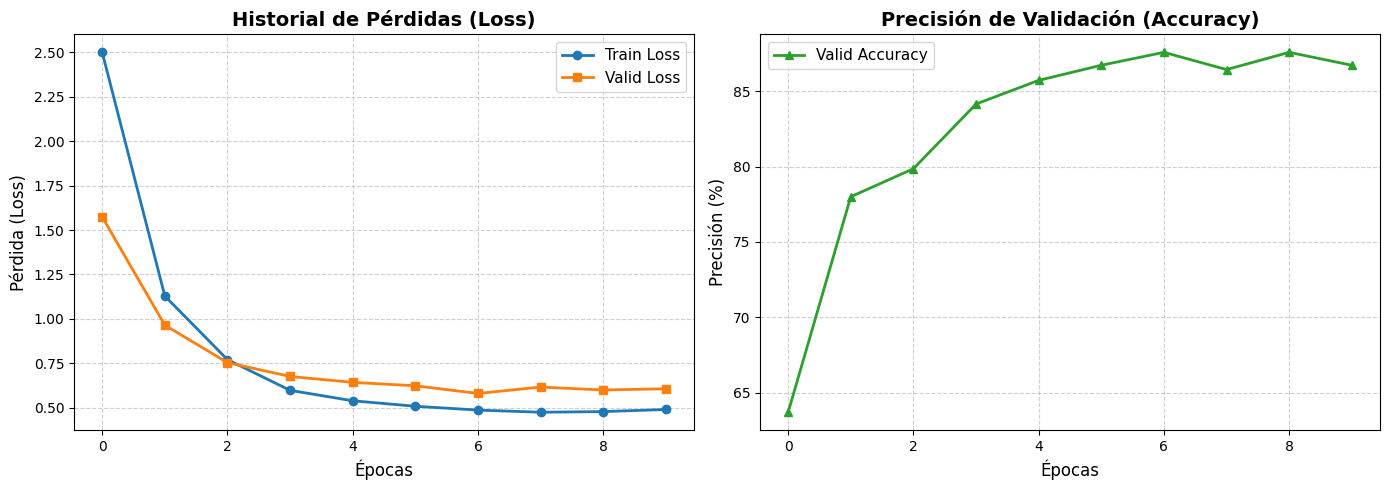

In [35]:
import matplotlib.pyplot as plt

# Configurar el estilo y tamaño del gráfico
plt.figure(figsize=(14, 5))


# GRAFICA 1: Pérdidas (Loss) - Entrenamiento vs Validación

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(valid_losses, label='Valid Loss', color='#ff7f0e', linewidth=2, marker='s')

plt.title('Historial de Pérdidas (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)


# GRÁFICA 2: Precisión (Accuracy) de Validación

plt.subplot(1, 2, 2)
# Multiplicamos por 100 para tener el porcentaje
valid_acc_percentage = [acc * 100 for acc in valid_accuracies]
plt.plot(valid_acc_percentage, label='Valid Accuracy', color='#2ca02c', linewidth=2, marker='^')

plt.title('Precisión de Validación (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Ajustar diseño para que no se encimen los textos y mostrar
plt.tight_layout()
plt.show()

Graficando las 12 clases con el rendimiento más bajo:
 - ID 4: american_spaniel
 - ID 16: boston_terrier
 - ID 23: chinese_crested
 - ID 24: chow
 - ID 26: cockapoo
 - ID 37: german_sheperd
 - ID 39: great_dane
 - ID 43: irish_spaniel
 - ID 47: labradoodle
 - ID 49: lhasa
 - ID 51: maltese
 - ID 59: rhodesian


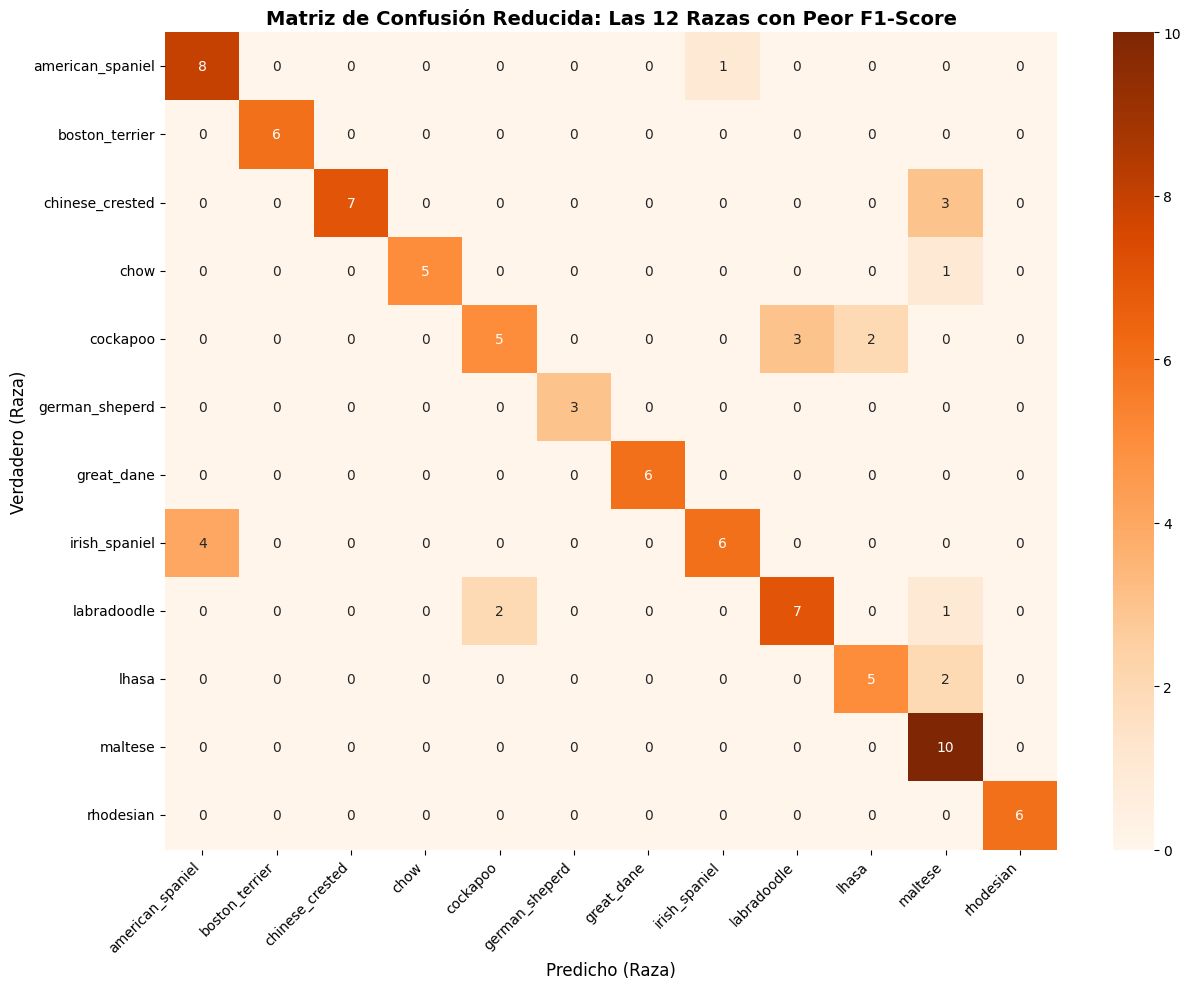

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer los nombres de las clases en el orden correcto
# PyTorch suele guardarlos en dataset.classes. Si usaste ImageFolder, es así:
nombres_de_clases = train_loader.dataset.classes

# 2. Obtener el reporte de métricas por clase
reporte = classification_report(y_true, y_pred, output_dict=True)

# 3. Extraer los F1-Scores de cada clase mapeando su ID con su Nombre
metricas_clases = []
for llave, metricas in reporte.items():
    if llave.isdigit():  # Solo IDs numéricos
        idx = int(llave)
        metricas_clases.append({
            'clase_id': idx,
            'nombre_clase': nombres_de_clases[idx], # <--- Mapeamos el ID al nombre real
            'f1-score': metricas['f1-score']
        })

# Convertir a DataFrame para ordenar fácilmente
df_metricas = pd.DataFrame(metricas_clases)

# 4. Seleccionamos las N peores clases (por ejemplo, las 12 con peor F1-Score)
N_PEORES = 12
df_peores = df_metricas.nsmallest(N_PEORES, 'f1-score').sort_values('clase_id')

indices_peores = df_peores['clase_id'].tolist()
nombres_peores = df_peores['nombre_clase'].tolist() # <--- Lista de nombres para los ejes

print(f"Graficando las {N_PEORES} clases con el rendimiento más bajo:")
for i, nombre in zip(indices_peores, nombres_peores):
    print(f" - ID {i}: {nombre}")

# 5. Calcular y filtrar la matriz de confusión completa usando los índices numéricos
cm_completa = confusion_matrix(y_true, y_pred)
cm_filtrada = cm_completa[np.ix_(indices_peores, indices_peores)]

# 6. Dibujar el mapa de calor (Heatmap) con los nombres en los ejes
plt.figure(figsize=(13, 10)) # Un poco más ancho para que entren bien los nombres de los perros
sns.heatmap(
    cm_filtrada,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=nombres_peores,
    yticklabels=nombres_peores
)

plt.title(f'Matriz de Confusión Reducida: Las {N_PEORES} Razas con Peor F1-Score', fontsize=14, fontweight='bold')
plt.xlabel('Predicho (Raza)', fontsize=12)
plt.ylabel('Verdadero (Raza)', fontsize=12)

# Rotamos los nombres del eje X para que no se superpongan si son largos
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

In [38]:
import torch.nn as nn
import torch

class CNNPropia(nn.Module):
    def __init__(self, num_classes=70):
        super(CNNPropia, self).__init__()

        # Bloque 1: Entran 3 canales (RGB), salen 32 filtros
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Estabilizador
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloque 2: Entran 32, salen 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Bloque 3: Entran 64, salen 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Bloque 4: Entran 128, salen 256 (Le damos más "cerebro" para captar 70 razas)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling para reducir los parámetros al mínimo necesario
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Clasificador final con Dropout FUERTE para matar el Overfitting
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x) # Apagamos neuronas antes de decidir
        x = self.fc(x)
        return x

# Instanciamos la nueva red
modelo_propio = CNNPropia(num_classes=70).to(device)
print("CNN cargada en la GPU")

CNN cargada en la GPU


In [39]:
from google.colab import drive
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/modelos_perros'
os.makedirs(drive_path, exist_ok=True)
print(f"Directorio de guardado confirmado en: {drive_path}\n")


EPOCHS_CNN = 15
LEARNING_RATE_CNN = 1e-3

print("=== Iniciando Entrenamiento de CNN Propia ===")

# Asegurarnos de que el modelo esté en la GPU
modelo_propio = modelo_propio.to(device)

criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.AdamW(modelo_propio.parameters(), lr=LEARNING_RATE_CNN, weight_decay=1e-4)
scheduler_cnn = StepLR(optimizer_cnn, step_size=4, gamma=0.5)

train_losses_cnn = []
valid_losses_cnn = []
valid_accuracies_cnn = []

best_valid_loss_cnn = float('inf')
patience_cnn = 5
patience_counter_cnn = 0

inicio_total = time.time()


# BUCLE DE ENTRENAMIENTO

for epoch in range(EPOCHS_CNN):
    epoch_start_time = time.time()

    # --- FASE DE ENTRENAMIENTO ---
    modelo_propio.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = modelo_propio(images)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_cnn.append(epoch_loss)

    # --- FASE DE VALIDACIÓN ---
    modelo_propio.eval()
    running_valid_loss = 0.0
    correctas = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelo_propio(images)

            loss_v = criterion_cnn(outputs, labels)
            running_valid_loss += loss_v.item() * images.size(0)

            _, predicciones = torch.max(outputs, 1)
            total += labels.size(0)
            correctas += (predicciones == labels).sum().item()

    epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
    epoch_acc = correctas / total

    valid_losses_cnn.append(epoch_valid_loss)
    valid_accuracies_cnn.append(epoch_acc)

    # --- MÉTRICAS Y TRACKING ---
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    current_lr = scheduler_cnn.get_last_lr()[0]

    print(f"Epoch [{epoch+1}/{EPOCHS_CNN}] ({epoch_duration:.1f}s) -> "
          f"LR: {current_lr:.7f} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Valid Loss: {epoch_valid_loss:.4f} | "
          f"Valid Acc: {epoch_acc:.4f}")

    # --- LÓGICA DE GUARDADO EN DRIVE ---
    if epoch_valid_loss < best_valid_loss_cnn:
        best_valid_loss_cnn = epoch_valid_loss
        patience_counter_cnn = 0

        best_model_path_cnn = os.path.join(drive_path, "cnn_custom.pth")
        torch.save(modelo_propio.state_dict(), best_model_path_cnn)
        print(f"  --> ¡Nueva mejor Validation Loss! Modelo guardado en: {best_model_path_cnn}")
    else:
        patience_counter_cnn += 1
        print(f"  --> La validación no mejoró. Conteo de paciencia: {patience_counter_cnn}/{patience_cnn}")

    scheduler_cnn.step()

    if patience_counter_cnn >= patience_cnn:
        print(f"\n[EARLY STOPPING] El entrenamiento se detuvo para evitar Overfitting.")
        break

fin_total = time.time()
minutos_totales = (fin_total - inicio_total) / 60
print(f"\nEntrenamiento finalizado en: {minutos_totales:.2f} minutos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio de guardado confirmado en: /content/drive/MyDrive/modelos_perros

=== Iniciando Entrenamiento de CNN Propia ===
Epoch [1/15] (64.0s) -> LR: 0.0010000 | Train Loss: 4.1653 | Valid Loss: 4.2392 | Valid Acc: 0.0243
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/cnn_custom.pth
Epoch [2/15] (65.4s) -> LR: 0.0010000 | Train Loss: 4.0173 | Valid Loss: 4.0123 | Valid Acc: 0.0443
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/cnn_custom.pth
Epoch [3/15] (65.4s) -> LR: 0.0010000 | Train Loss: 3.9300 | Valid Loss: 3.8657 | Valid Acc: 0.0586
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/cnn_custom.pth
Epoch [4/15] (65.1s) -> LR: 0.0010000 | Train Loss: 3.8784 | Valid Loss: 3.9135 | Valid Acc: 0.0500
  --> La validación n

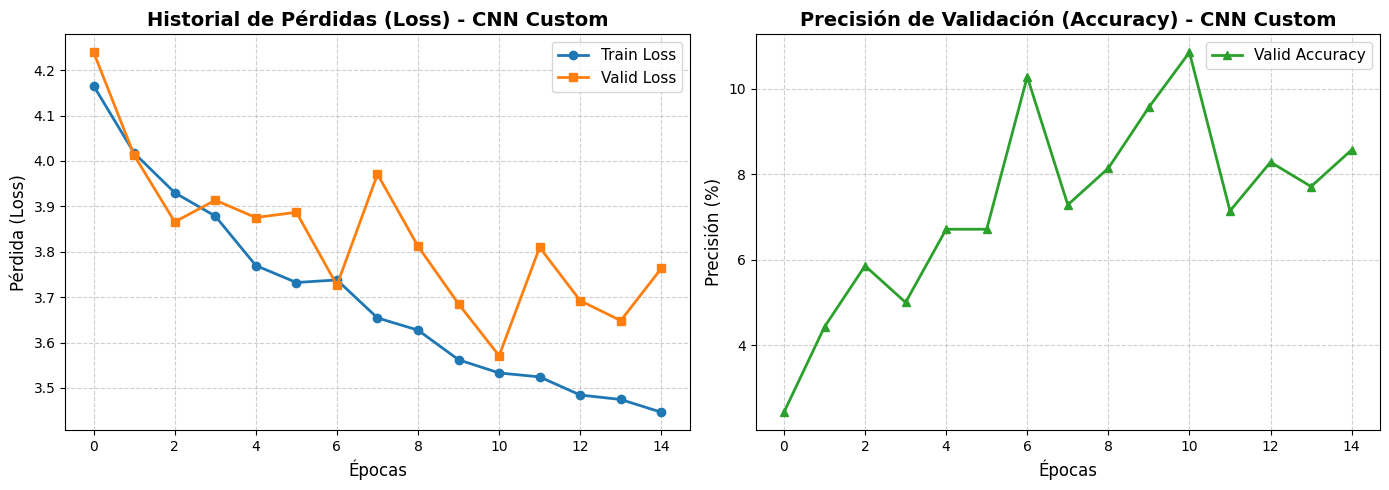

In [40]:
import matplotlib.pyplot as plt

# Configurar el estilo y tamaño del gráfico
plt.figure(figsize=(14, 5))


# GRAFICA 1: Pérdidas (Loss) - Entrenamiento vs Validación (CNN Custom)

plt.subplot(1, 2, 1)
plt.plot(train_losses_cnn, label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(valid_losses_cnn, label='Valid Loss', color='#ff7f0e', linewidth=2, marker='s')

plt.title('Historial de Pérdidas (Loss) - CNN Custom', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)


# GRÁFICA 2: Precisión (Accuracy) de Validación (CNN Custom)

plt.subplot(1, 2, 2)
# Multiplicamos por 100 para tener el porcentaje
valid_acc_percentage_cnn = [acc * 100 for acc in valid_accuracies_cnn]
plt.plot(valid_acc_percentage_cnn, label='Valid Accuracy', color='#2ca02c', linewidth=2, marker='^')

plt.title('Precisión de Validación (Accuracy) - CNN Custom', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Ajustar diseño para que no se encimen los textos y mostrar
plt.tight_layout()
plt.show()

In [ ]:
# classifier.set_active_model("cnn_custom")
# classifier.train_classifier()
# metrics_b = classifier.evaluate_classifier()
# metrics_b

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

In [ ]:
## TO-DO: comparacion entre modelos y analisis de errores.

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
# import os
# import gdown

# def descargar_modelos_publicos():
#     directorio_destino = "models"
#     os.makedirs(directorio_destino, exist_ok=True)

#     print("=== Iniciando descarga desde Google Drive público ===")

#     # link de carpeta pública
#     carpeta_url = "https://drive.google.com/drive/folders/1mETabyHldM6zGE72jBN8ALgIsLpr-vHm"

#     try:
#         gdown.download_folder(url=carpeta_url, output=directorio_destino, quiet=False, use_cookies=False)
#         print(f"\n¡Modelos descargados exitosamente en la carpeta '{directorio_destino}'!")
#     except Exception as e:
#         print(f"\n Ocurrió un error en la descarga: {e}")
#         print("Asegurate de que la carpeta de Drive esté configurada como 'Cualquier persona con el enlace puede leer'.")

# if __name__ == "__main__":
#     descargar_modelos_publicos()

In [ ]:
# !ls -lh models/

# try:
#     from google.colab import files

#     files.download(str(settings.model_path / settings.resnet18_model_name))
#     # files.download(str(settings.model_path / settings.cnn_custom_model_name))
# except ImportError:
#     print("Fuera de Colab: los checkpoints quedan en models/")